In [1]:
import sys

print(sys.executable)
print(sys.version)

/var/home/dromero/dev/learning/mlops-tec/week-01/03-hello-mlflow/.venv/bin/python
3.14.7 (main, Aug 10 2026, 00:00:00) [GCC 16.1.1 20260515 (Red Hat 16.1.1-2)]


In [3]:
# dataset
import pandas as pd

df = pd.read_excel("Attribute DataSet.xlsx")

df.head()

,Dress_ID,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,waiseline,Material,FabricType,Decoration,Pattern Type,Recommendation
0,1006032852,Sexy,Low,4.6,M,Summer,o-neck,sleevless,empire,NaN,chiffon,ruffles,animal,1
1,1212192089,Casual,Low,0.0,L,Summer,o-neck,Petal,natural,microfiber,NaN,ruffles,animal,0
2,1190380701,vintage,High,0.0,L,Automn,o-neck,full,natural,polyster,NaN,NaN,print,0
3,966005983,Brief,Average,4.6,L,Spring,o-neck,full,natural,silk,chiffon,embroidary,print,1
4,876339541,cute,Low,4.5,M,Summer,o-neck,butterfly,natural,chiffonfabric,chiffon,bow,dot,0


## Descripción y analisis del dataset

El dataset Dresses Attribute Sales contiene información sobre características de diferentes vestidos y una variable de recomendación.

El objetivo de este análisis es explorar la calidad y distribución de los datos, realizar las transformaciones necesarias y construir un modelo baseline capaz de predecir la variable `Recommendation`.

In [5]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por variable:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores de Recommendation:")
print(df["Recommendation"].value_counts())

Dimensiones del dataset:
(500, 14)

Tipos de datos:
Dress_ID            int64
Style                 str
Price                 str
Rating            float64
Size                  str
Season                str
NeckLine              str
SleeveLength          str
waiseline             str
Material              str
FabricType            str
Decoration            str
Pattern Type          str
Recommendation      int64
dtype: object

Valores nulos por variable:
Dress_ID            0
Style               0
Price               2
Rating              0
Size                0
Season              2
NeckLine            3
SleeveLength        2
waiseline          87
Material          128
FabricType        266
Decoration        236
Pattern Type      109
Recommendation      0
dtype: int64

Registros duplicados:
0

Valores de Recommendation:
Recommendation
0    290
1    210
Name: count, dtype: int64


In [6]:
categorical_columns = [
    "Style",
    "Price",
    "Size",
    "Season",
    "NeckLine",
    "SleeveLength",
    "waiseline",
    "Material",
    "FabricType",
    "Decoration",
    "Pattern Type"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"{'=' * 50}")
    print(df[column].value_counts(dropna=False))


Style
Style
Casual      232
Sexy         69
party        51
cute         45
vintage      25
bohemian     24
Brief        18
work         17
Novelty       8
sexy          7
Flare         2
OL            1
fashion       1
Name: count, dtype: int64

Price
Price
Average      252
Low          129
low           45
Medium        30
very-high     21
high          15
High           6
NaN            2
Name: count, dtype: int64

Size
Size
M        177
free     173
L         96
S         37
XL        15
small      1
s          1
Name: count, dtype: int64

Season
Season
Summer    159
Spring    122
Winter     99
Automn     61
winter     46
Autumn      8
spring      2
NaN         2
summer      1
Name: count, dtype: int64

NeckLine
NeckLine
o-neck             271
v-neck             124
slash-neck          25
boat-neck           19
Sweetheart          14
turndowncollor      13
bowneck             10
peterpan-collor      6
sqare-collor         5
open                 3
NaN                  3
Scoop      

In [11]:
print(df["Price"].value_counts(dropna=False))

Price
Average      252
Low          129
low           45
Medium        30
very-high     21
high          15
High           6
NaN            2
Name: count, dtype: int64


In [9]:
for column in categorical_columns:
    values_with_spaces = df[column].dropna().astype(str)

    has_spaces = values_with_spaces[
        values_with_spaces.str.strip() != values_with_spaces
    ]

    if len(has_spaces) > 0:
        print(f"{column}:")
        print(has_spaces.unique())

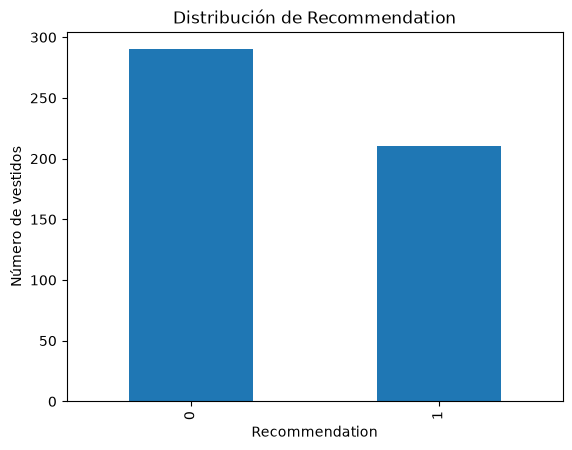

In [12]:
import matplotlib.pyplot as plt

df["Recommendation"].value_counts().plot(kind="bar")

plt.title("Distribución de Recommendation")
plt.xlabel("Recommendation")
plt.ylabel("Número de vestidos")
plt.show()

In [13]:
df["Rating"].describe()

count    500.000000
mean       3.528600
std        2.005364
min        0.000000
25%        3.700000
50%        4.600000
75%        4.800000
max        5.000000
Name: Rating, dtype: float64

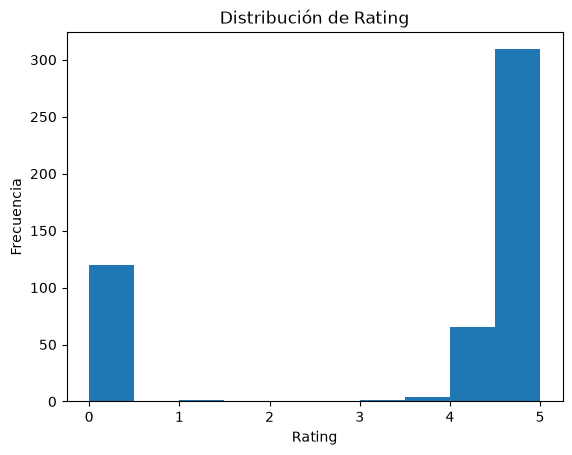

In [14]:
df["Rating"].plot(kind="hist", bins=10)

plt.title("Distribución de Rating")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

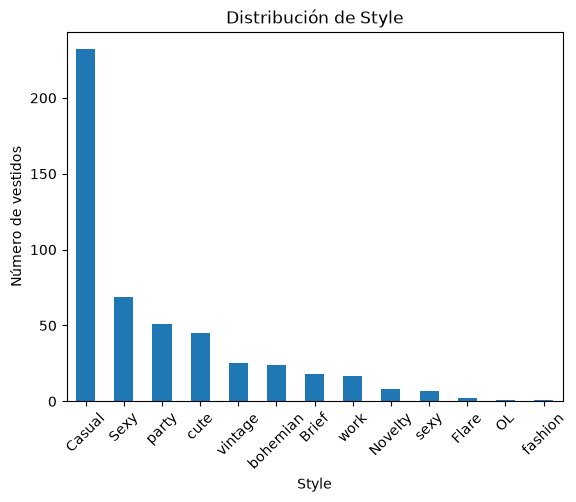

In [15]:
df["Style"].value_counts().plot(kind="bar")

plt.title("Distribución de Style")
plt.xlabel("Style")
plt.ylabel("Número de vestidos")
plt.xticks(rotation=45)
plt.show()

In [16]:
pd.crosstab(
    df["Price"],
    df["Recommendation"],
    normalize="index"
)

Recommendation,0,1
Price,,
Average,0.634921,0.365079
High,0.666667,0.333333
Low,0.581395,0.418605
Medium,0.366667,0.633333
high,0.533333,0.466667
low,0.600000,0.400000
very-high,0.238095,0.761905


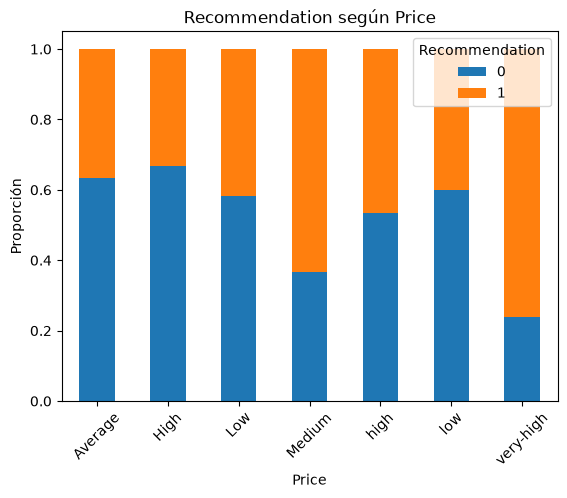

In [17]:
pd.crosstab(
    df["Price"],
    df["Recommendation"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.title("Recommendation según Price")
plt.xlabel("Price")
plt.ylabel("Proporción")
plt.legend(title="Recommendation")
plt.xticks(rotation=45)
plt.show()

In [18]:
print("Cantidad de Rating = 0:")
print((df["Rating"] == 0).sum())

print("\nRecommendation cuando Rating = 0:")
print(
    df.loc[df["Rating"] == 0, "Recommendation"]
    .value_counts()
)

print("\nProporción de Recommendation cuando Rating = 0:")
print(
    df.loc[df["Rating"] == 0, "Recommendation"]
    .value_counts(normalize=True)
)

Cantidad de Rating = 0:
120

Recommendation cuando Rating = 0:
Recommendation
0    73
1    47
Name: count, dtype: int64

Proporción de Recommendation cuando Rating = 0:
Recommendation
0    0.608333
1    0.391667
Name: proportion, dtype: float64


In [21]:
print("Cantidad de Rating = 0:")
print((df["Rating"] == 0).sum())

print("\nRecommendation cuando Rating = 0:")
print(
    df.loc[df["Rating"] == 0, "Recommendation"]
    .value_counts()
)

print("\nProporción de Recommendation cuando Rating = 0:")
print(
    df.loc[df["Rating"] == 0, "Recommendation"]
    .value_counts(normalize=True)
)

Cantidad de Rating = 0:
120

Recommendation cuando Rating = 0:
Recommendation
0    73
1    47
Name: count, dtype: int64

Proporción de Recommendation cuando Rating = 0:
Recommendation
0    0.608333
1    0.391667
Name: proportion, dtype: float64


In [ ]:
X = df.drop(columns=["Recommendation", "Dress_ID"])
y = df["Recommendation"]

In [22]:
# Crear una copia para conservar intacto el dataset original
df_clean = df.copy()

# Variables categóricas
categorical_columns = [
    "Style",
    "Price",
    "Size",
    "Season",
    "NeckLine",
    "SleeveLength",
    "waiseline",
    "Material",
    "FabricType",
    "Decoration",
    "Pattern Type"
]

# 1. Normalizar espacios y mayúsculas/minúsculas
for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

# 2. Corregir categorías inequívocamente equivalentes

# Style
df_clean["Style"] = df_clean["Style"].replace({
    "sexy": "sexy"
})

# Size
df_clean["Size"] = df_clean["Size"].replace({
    "small": "s",
    "s": "s"
})

# Season
df_clean["Season"] = df_clean["Season"].replace({
    "automn": "autumn"
})

# SleeveLength
df_clean["SleeveLength"] = df_clean["SleeveLength"].replace({
    "sleeveless": "sleeveless",
    "sleeevless": "sleeveless",
    "sleveless": "sleeveless",
    "sleevless": "sleeveless",
    "threequarter": "threequarter",
    "thressqatar": "threequarter",
    "threequater": "threequarter",
    "capsleeves": "capsleeves",
    "cap-sleeves": "capsleeves"
})

# 3. Representar explícitamente los valores categóricos faltantes
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna("unknown")

# Mostrar dimensiones después de la limpieza
print("Dimensiones después de la limpieza:", df_clean.shape)

# Verificar valores faltantes
print("\nValores nulos después de la limpieza:")
print(df_clean.isnull().sum())

Dimensiones después de la limpieza: (500, 14)

Valores nulos después de la limpieza:
Dress_ID          0
Style             0
Price             0
Rating            0
Size              0
Season            0
NeckLine          0
SleeveLength      0
waiseline         0
Material          0
FabricType        0
Decoration        0
Pattern Type      0
Recommendation    0
dtype: int64


## Limpieza y preparación de datos

A partir del análisis exploratorio se identificaron valores faltantes, inconsistencias de escritura y categorías duplicadas por diferencias de capitalización.

Las decisiones de limpieza fueron:

- No se encontraron registros duplicados, por lo que no fue necesario eliminarlos.
- Las variables categóricas fueron normalizadas mediante eliminación de espacios innecesarios y conversión a minúsculas.
- Se unificaron categorías inequívocamente equivalentes, como `Automn` y `Autumn`, así como diferentes variantes de `SleeveLength`.
- En `Size`, las categorías `small` y `s` fueron unificadas como `s`.
- Los valores faltantes de variables categóricas fueron reemplazados por la categoría `unknown`, evitando eliminar observaciones y conservando los 500 registros disponibles.
- Los 120 valores de `Rating` iguales a 0 se conservaron, ya que el análisis no permitió determinar que representaran valores faltantes. Estos registros presentan tanto recomendaciones 0 como 1.
- `Dress_ID` se conservará en el dataframe para trazabilidad, pero no se utilizará como variable predictora debido a que funciona como identificador del vestido.

Después de la limpieza se conservaron las 500 observaciones originales y no quedaron valores nulos en el dataset.

In [25]:
X = df.drop(columns=["Recommendation", "Dress_ID"])
y = df["Recommendation"]

In [26]:
# Variables predictoras y variable objetivo después de la limpieza
X = df_clean.drop(columns=["Recommendation", "Dress_ID"])
y = df_clean["Recommendation"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (500, 12)
Dimensiones de y: (500,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 12)
X_test: (100, 12)
y_train: (400,)
y_test: (100,)


In [28]:
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución en entrenamiento:
Recommendation
0    0.58
1    0.42
Name: proportion, dtype: float64

Distribución en prueba:
Recommendation
0    0.58
1    0.42
Name: proportion, dtype: float64


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ["Rating"]

categorical_features = [
    "Style",
    "Price",
    "Size",
    "Season",
    "NeckLine",
    "SleeveLength",
    "waiseline",
    "Material",
    "FabricType",
    "Decoration",
    "Pattern Type"
]

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: ['Rating']
Variables categóricas: ['Style', 'Price', 'Size', 'Season', 'NeckLine', 'SleeveLength', 'waiseline', 'Material', 'FabricType', 'Decoration', 'Pattern Type']


In [31]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [33]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [34]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_model)
    ]
)

In [35]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Style','Price','Rating',...,'FabricType','Decoration','Pattern Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all 

In [36]:
y_pred = model_pipeline.predict(X_test)

print("Primeras predicciones:")
print(y_pred[:20])

Primeras predicciones:
[0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0]


In [37]:
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("Primeras probabilidades:")
print(y_pred_proba[:10])

Primeras probabilidades:
[0.42143081 0.5166106  0.80106261 0.30325366 0.62082709 0.14737281
 0.2275104  0.43227059 0.42579114 0.36994317]


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.5700
Precision: 0.4815
Recall:    0.3095
F1-score:  0.3768

Matriz de confusión:
[[44 14]
 [29 13]]

Classification report:
              precision    recall  f1-score   support

           0       0.60      0.76      0.67        58
           1       0.48      0.31      0.38        42

    accuracy                           0.57       100
   macro avg       0.54      0.53      0.52       100
weighted avg       0.55      0.57      0.55       100



## Evaluación del modelo baseline

Se utilizó Logistic Regression como modelo baseline, integrado con un pipeline de preprocesamiento que aplica imputación y One-Hot Encoding a las variables categóricas.

El modelo obtuvo los siguientes resultados en el conjunto de prueba:

- Accuracy: 0.5700
- Precision: 0.4815
- Recall: 0.3095
- F1-score: 0.3768

La matriz de confusión mostró 44 verdaderos negativos, 14 falsos positivos, 29 falsos negativos y 13 verdaderos positivos.

El modelo presenta dificultades particularmente para identificar la clase `Recommendation = 1`. Su recall para esta clase fue de 30.95%, por lo que de los 42 casos positivos presentes en el conjunto de prueba solamente 13 fueron identificados correctamente.

La accuracy de 57% también debe interpretarse considerando la distribución original del target, donde la clase 0 representa el 58% de las observaciones. Por lo tanto, el resultado del baseline no demuestra una mejora respecto a una estrategia trivial que siempre predijera la clase mayoritaria. Esto justifica utilizar métricas adicionales como precision, recall y F1-score en lugar de evaluar el modelo únicamente mediante accuracy.

Este resultado representa una línea base para experimentos posteriores. Una siguiente etapa podría investigar diferentes algoritmos, parámetros y estrategias de ingeniería de características, manteniendo el proceso de experimentación y evaluación trazable mediante MLflow.

In [39]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


In [41]:
print(mlflow.search_experiments())

[<Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1790819512703, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1790819512703, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]


In [42]:
mlflow.set_experiment("Dresses Attribute Sales - Baseline")

print("Experimento:", mlflow.get_experiment_by_name(
    "Dresses Attribute Sales - Baseline"
))

2026/09/30 19:54:09 INFO mlflow.tracking.fluent: Experiment with name 'Dresses Attribute Sales - Baseline' does not exist. Creating a new experiment.


Experimento: <Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790819649471, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790819649471, lifecycle_stage='active', name='Dresses Attribute Sales - Baseline', tags={}, trace_location=None, workspace='default'>


In [47]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="logistic-regression-baseline-model"):

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("encoding", "OneHotEncoder")
    mlflow.log_param("numeric_imputation", "median")
    mlflow.log_param("categorical_imputation", "most_frequent")

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    mlflow.set_tag("dataset", "Dresses Attribute Sales")
    mlflow.set_tag("model_type", "baseline")
    mlflow.set_tag(
        "description",
        "Baseline classification model using Logistic Regression"
    )

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="baseline_model",
        skops_trusted_types=["numpy.dtype"]
    )

    print("Run ID:", mlflow.active_run().info.run_id)

Run ID: ca47ef3bb9854d09b50bebba5e017d62
🏃 View run logistic-regression-baseline-model at: http://127.0.0.1:5000/#/experiments/1/runs/ca47ef3bb9854d09b50bebba5e017d62
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Evidencia de MLflow Tracking

El experimento `Dresses Attribute Sales - Baseline` fue registrado en MLflow mediante un run denominado `logistic-regression-baseline-model`.

El run registró los parámetros utilizados durante el entrenamiento, las métricas obtenidas sobre el conjunto de prueba y el modelo baseline completo, compuesto por el preprocesamiento y el clasificador Logistic Regression.

**Run ID:** `ca47ef3bb9854d09b50bebba5e017d62`

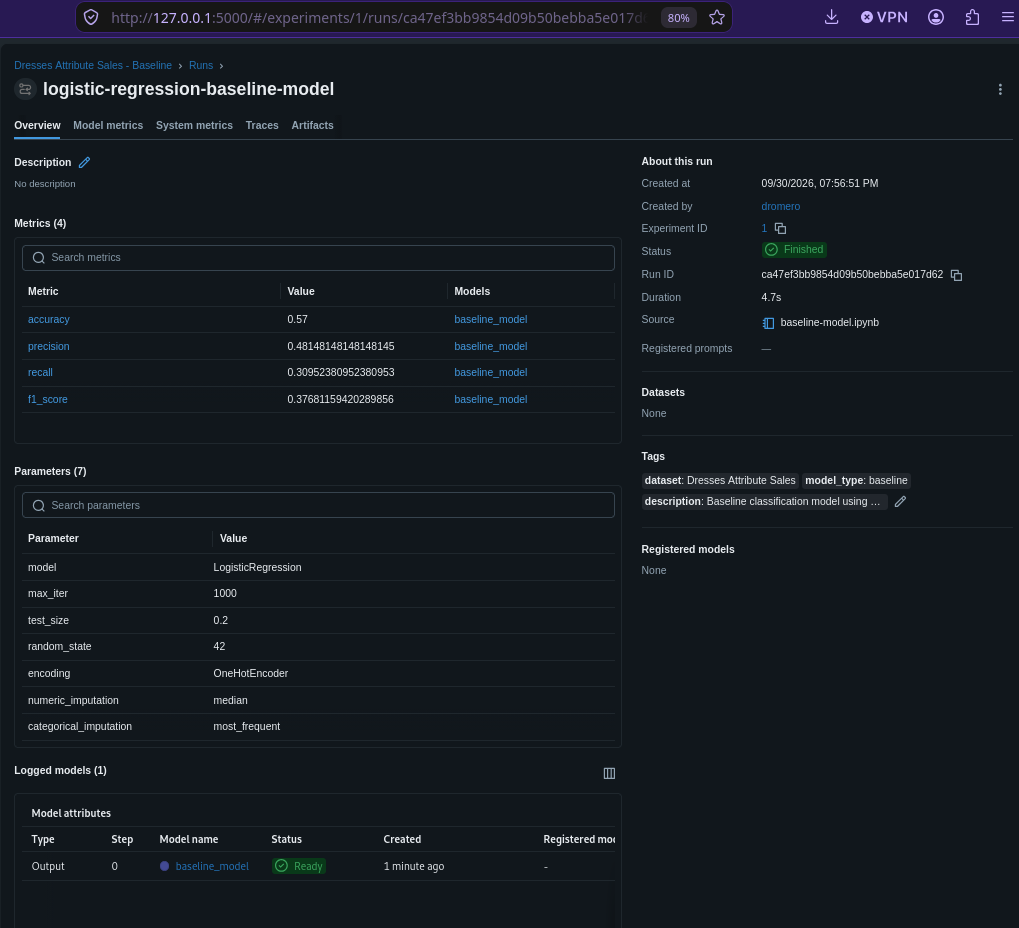